# Aula 03 - Amostragem, Interpolação e Quantização

In [1]:
# Representa e manipula matrizes
import numpy as np
# Exibe as imagens
import matplotlib.pyplot as plt

# Ler, converter, e redimensionar imagens
from PIL import Image
# Acessa imagens de exemplo
from skimage import data, color

In [2]:
def mostrar_imagem(imagem, titulo, cmap=None, barra_cores=False, tamanho=(4,4)):
    # Definindo Tamanho da imagem
    plt.figure(figsize=tamanho);

    plt.imshow(imagem, cmap=cmap, vmin=0, vmax=255)
    plt.title(titulo)
    plt.axis("off")

    if barra_cores:
        plt.colorbar()

    plt.show()

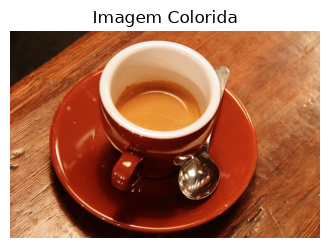

Dimensões: (400, 600, 3)
Tipo de Dado: uint8


In [3]:
imagem_rgb = data.coffee()

mostrar_imagem(
    imagem_rgb,
    titulo="Imagem Colorida"
)

print("Dimensões:", imagem_rgb.shape)
print("Tipo de Dado:", imagem_rgb.dtype)

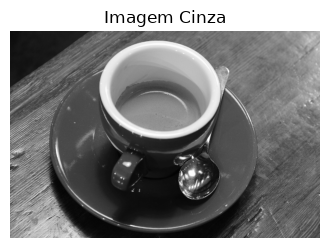

In [4]:
imagem_float = imagem_rgb

cinza_media = imagem_float.mean(axis=2).astype(np.uint8)
mostrar_imagem(
    cinza_media,
    titulo="Imagem Cinza",
    cmap="gray"
)

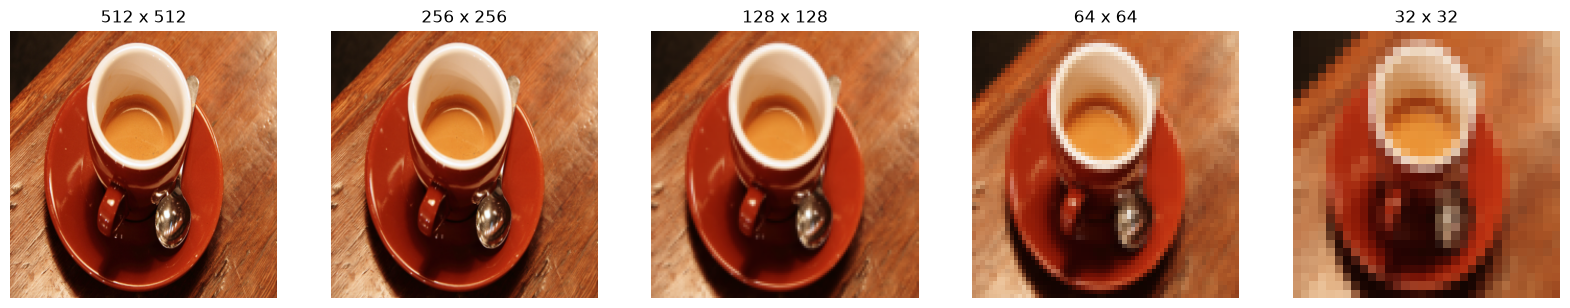

In [ ]:
# Amostragem - Determina quantidade de pontos utilizados pra representar uma imagem.

# REDUZINDO O TAMANHO DA IMAGEM

# Convertendo a imagem para uma forma em que o PILL trabalha
imagem_pil = Image.fromarray(imagem_rgb)

tamanhos = [
    (512, 512),
    (256, 256),
    (128, 128),
    (64, 64),
    (32, 32)
]

# fig - Representa a imagem completa
# eixos - Array de posições dentro da imagem
fig, eixos = plt.subplots(1, 5, figsize=(20,5))

for eixos, tamanho in zip(eixos, tamanhos):
    reduzida = imagem_pil.resize(
        tamanho,
        Image.Resampling.BILINEAR
    )

    # Definindo configurações para cada um dos eixos
    eixos.imshow(reduzida)
    eixos.set_title(f"{tamanho[0]} x {tamanho[1]}")
    eixos.axis("off")

plt.show()

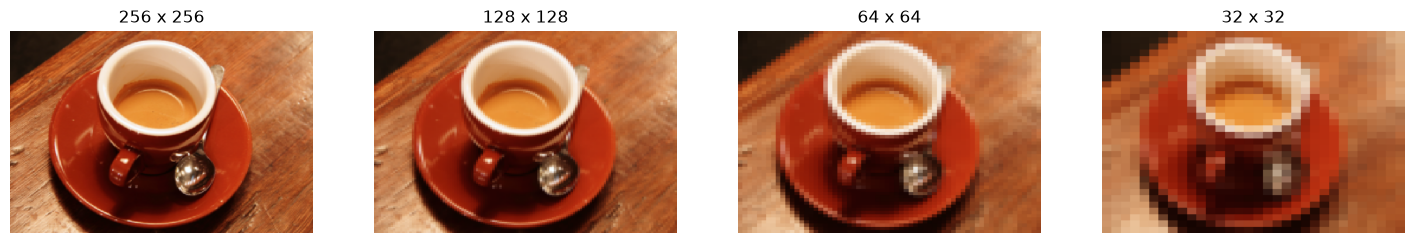

(600, 400)


In [ ]:
# REDUZINDO A QUALIDADE DA IMAGEM

# Pegando o tamanho da imagem pra armazenar 
tamanho_original = imagem_pil.size

resolucoes = [256, 128, 64, 32]


fig, eixos = plt.subplots(1, len(resolucoes), figsize=(18,5))

for eixos, resolucoes in zip(eixos, resolucoes):
    reduzida = imagem_pil.resize(
        (resolucoes, resolucoes),
        Image.Resampling.BILINEAR
    )

    ampliada = reduzida.resize(
        tamanho_original,
        Image.Resampling.NEAREST
    )

    # Definindo configurações para cada um dos eixos
    eixos.imshow(ampliada)
    eixos.set_title(f"{resolucoes} x {resolucoes}")
    eixos.axis("off")
    
plt.show()

print(imagem_pil.size)

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

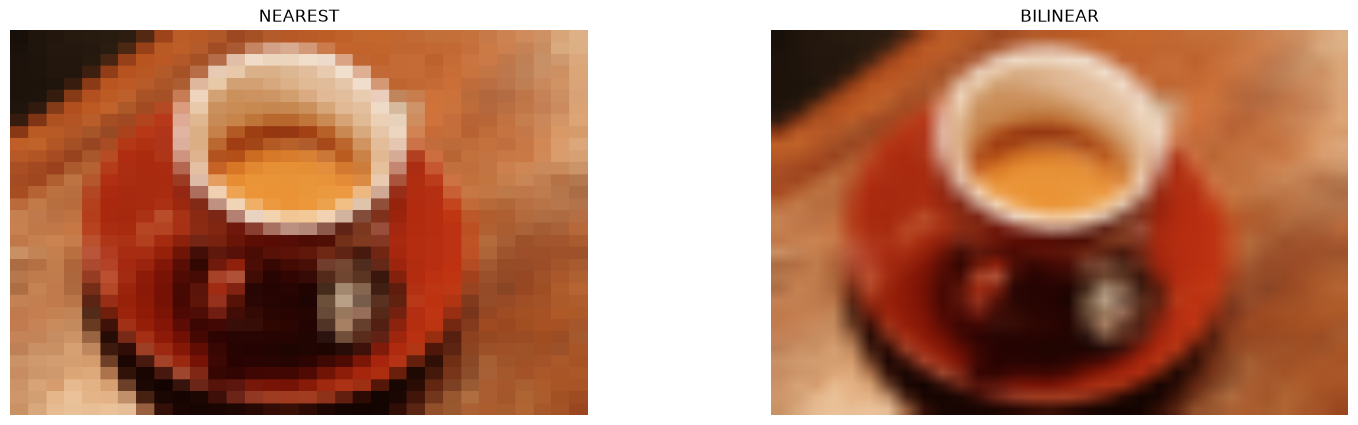

In [ ]:
reduzida = imagem_pil.resize(
    (32, 32),
    Image.Resampling.BILINEAR
    # Image.Resampling.NEAREST
)

ampliada_1 = reduzida.resize(
    tamanho_original,
    Image.Resampling.NEAREST
)

ampliada_2 = reduzida.resize(
    tamanho_original,
    Image.Resampling.BILINEAR
)

fig, eixos = plt.subplots(1, 2, figsize=(18,5))

# Definindo configurações para cada um dos eixos
eixos[0].imshow(ampliada_1)
eixos[0].set_title(f"NEAREST")
eixos[0].axis("off")

eixos[1].imshow(ampliada_2)
eixos[1].set_title(f"BILINEAR")
eixos[1].axis("off")

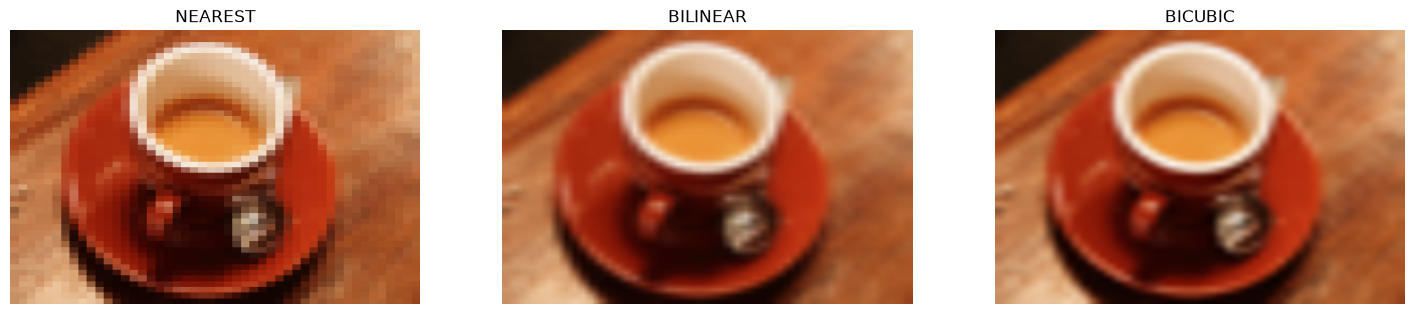

In [19]:
imagem_reduzida = imagem_pil.resize(
    (48,48),
    Image.Resampling.BILINEAR
)

metodos = {
    "NEAREST": Image.Resampling.NEAREST,
    "BILINEAR": Image.Resampling.BILINEAR,
    "BICUBIC": Image.Resampling.BICUBIC,
}

fig, eixos = plt.subplots(1, 3, figsize=(18,6))

for eixo, (nome, metodo) in zip(eixos, metodos.items()):
    ampliada = imagem_reduzida.resize(
        tamanho_original,
        metodo
    )

    eixo.imshow(ampliada)
    eixo.set_title(nome)
    eixo.axis("off")

plt.show()

In [5]:
# QUANTIZAÇÃO
# Refere-se a quantos níveis podem ser utilizados para representar uma imagem

def quantizacao(imagem, quantidade_niveis):

    # Passando a imagem para intervalo de 0 ... 1
    imagem_normalizada = imagem.astype(np.float32) / 255.0

    # Arredondando os valores para cada um dos níveis
    indice = np.round(
        imagem_normalizada * (quantidade_niveis - 1)
    )

    # Passando a imagem para o intervalo de 0 ... 255
    quantizada = (
        indice / (quantidade_niveis - 1 ) * 255
    )

    return quantizada.astype(np.uint8)


TypeError: 'int' object is not subscriptable

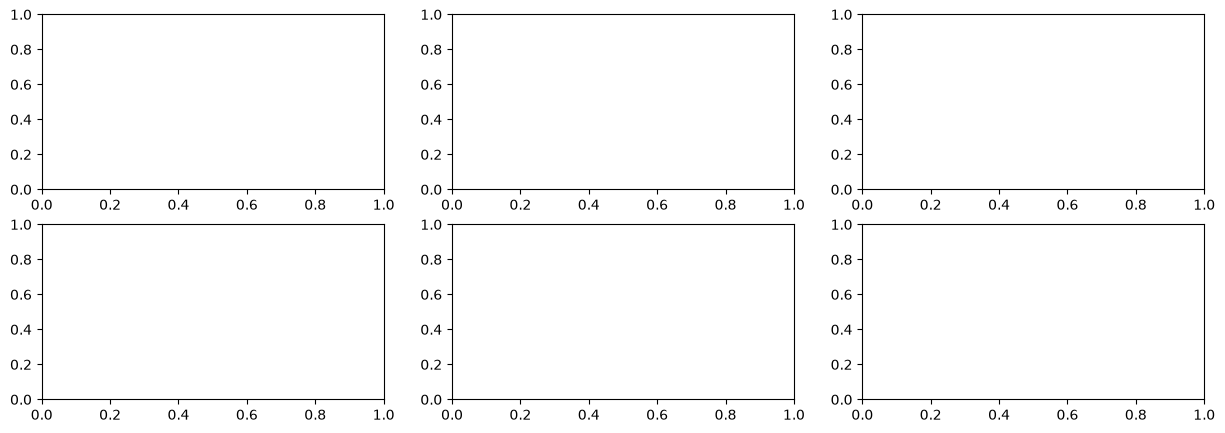

In [ ]:
niveis = [256, 32, 16, 8, 4, 2]

fig, eixos = plt.subplots(2, 3, figsize=(15,5))

# ravel() - Transforma matriz em um vetor
for eixo, quantidade in zip([0,0,2,2,4,4], niveis):
    quantizada = quantizacao(
        cinza_media,
        quantidade 
    )

    eixo.imshow(quantizada, cmap="gray")
    eixo.set_title(f"{quantidade}")
    eixo.axis('off')

plt.show()

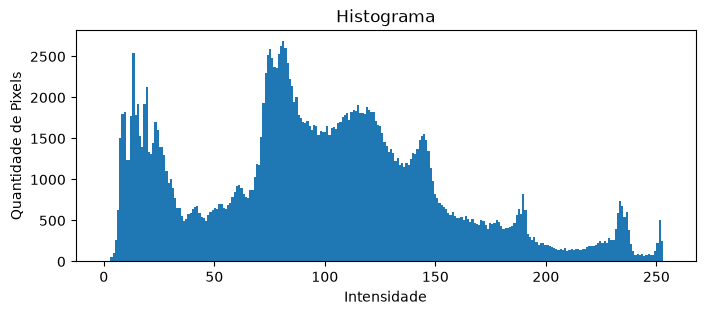

In [18]:
# HISTOGRAMA
plt.figure(figsize=(8,3))
plt.hist(
    # Imagem Utilizada
    cinza_media.ravel(),
    # Variância
    bins=256,
    # Intervalo
    range=(0, 255)
)

plt.title("Histograma")
plt.xlabel("Intensidade")
plt.ylabel("Quantidade de Pixels")
plt.show()

In [22]:
def mostrar_imagem_histograma(imagem, titulo="Imagem"):
    fig, eixos = plt.subplots(1, 2, figsize=(16,6))

    eixos[0].imshow(imagem, cmap='gray', vmin=0, vmax=255)
    eixos[0].set_title(titulo)
    eixos[0].axis("off")

    eixos[1].hist(
        imagem.ravel(),
        bins = 256,
        range = (0, 255)
    )
    eixos[1].set_title("Histograma")
    eixos[1].set_xlabel("Intensidade")
    eixos[1].set_ylabel("Quantidade de Pixels")

    plt.show()

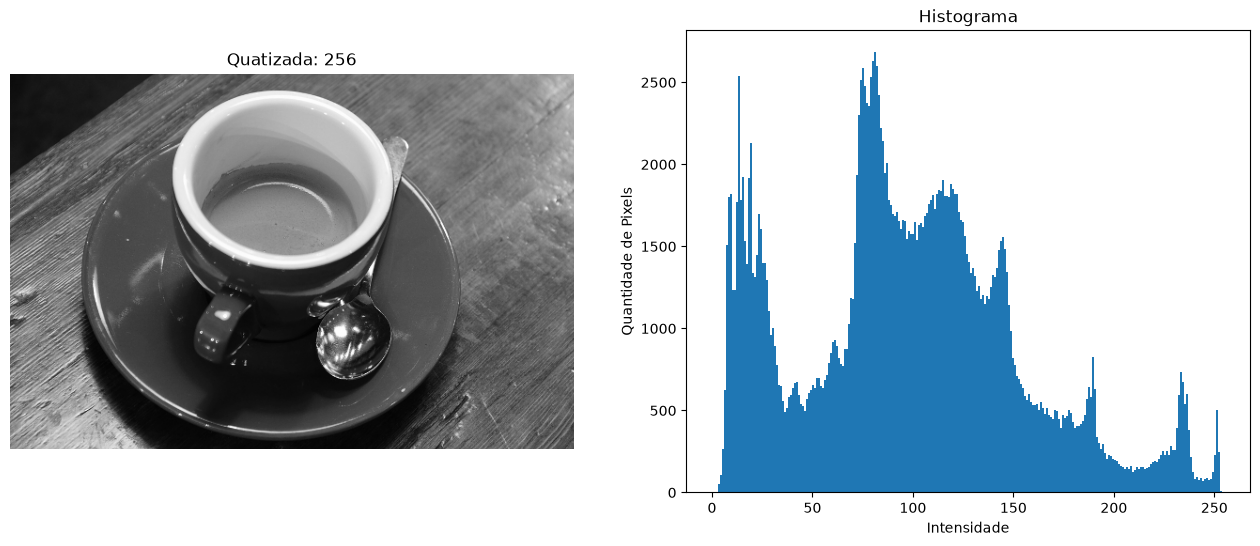

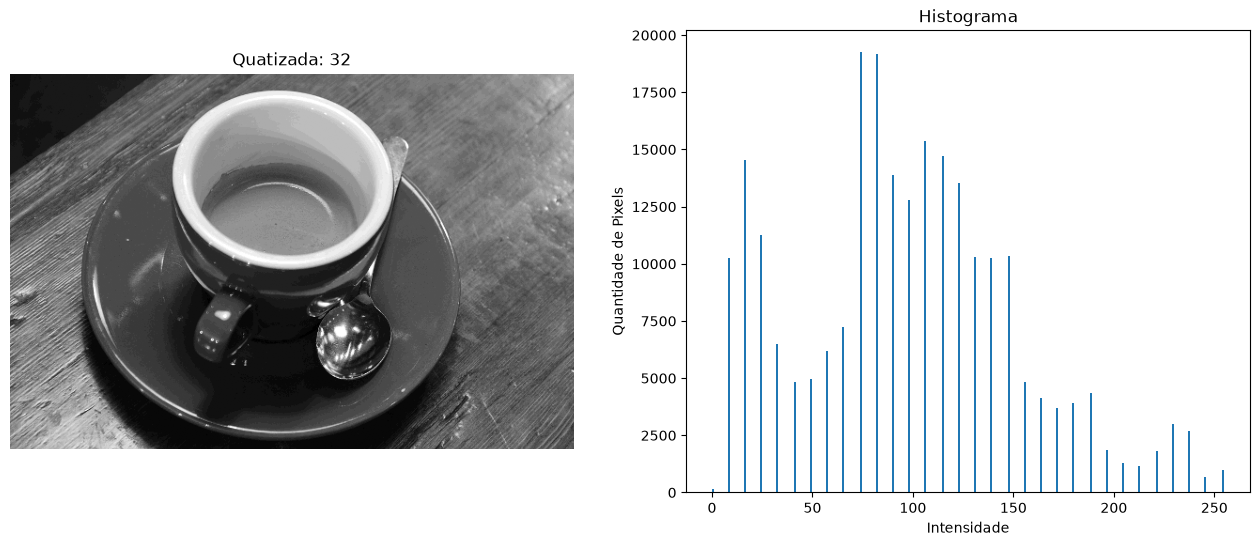

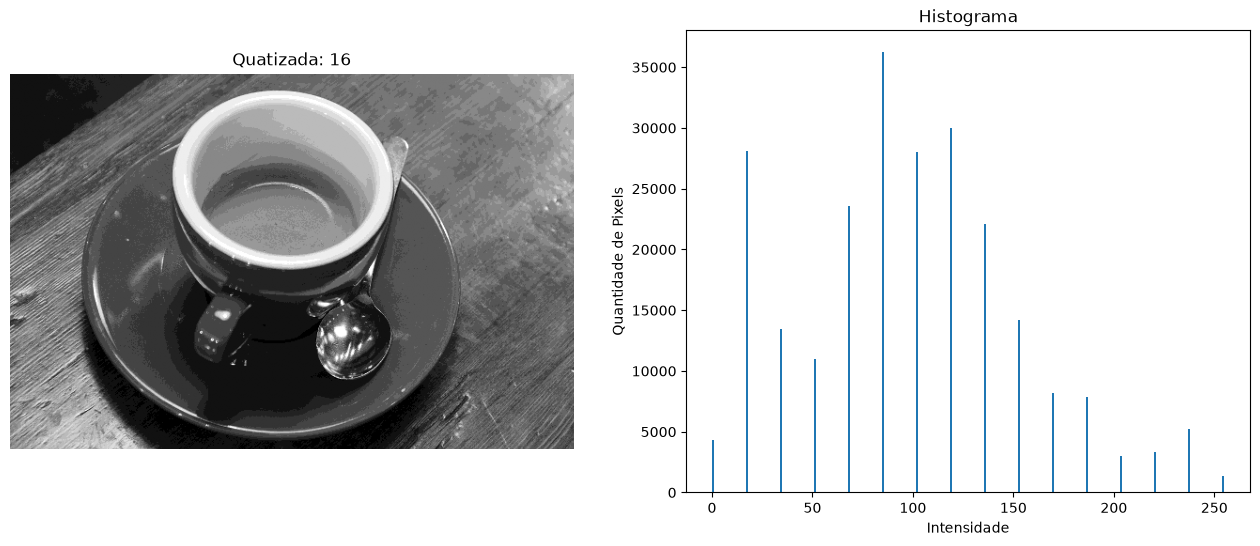

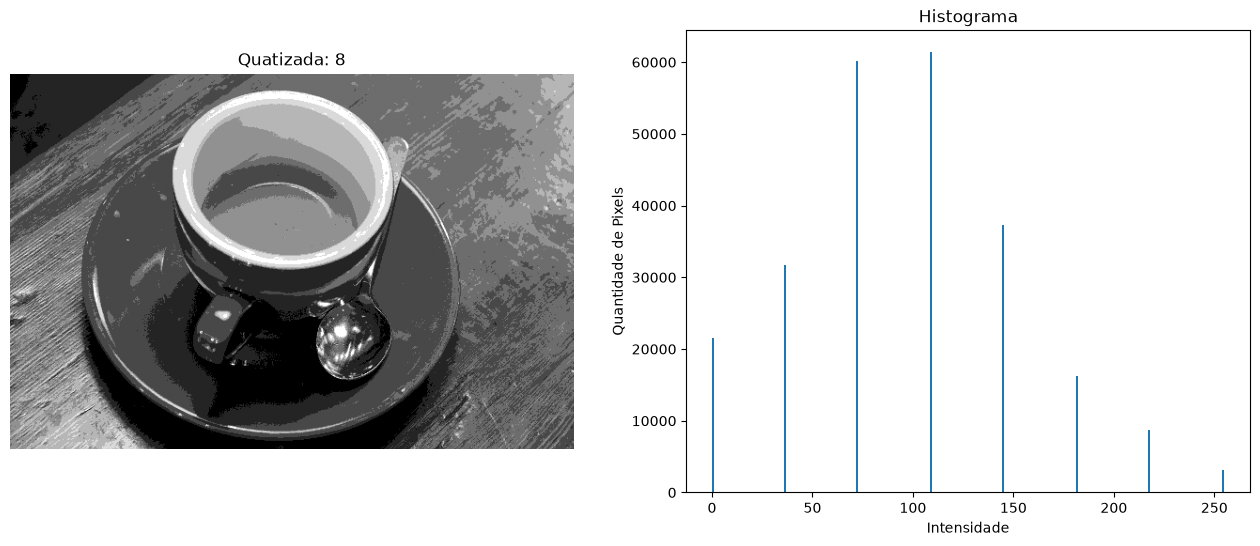

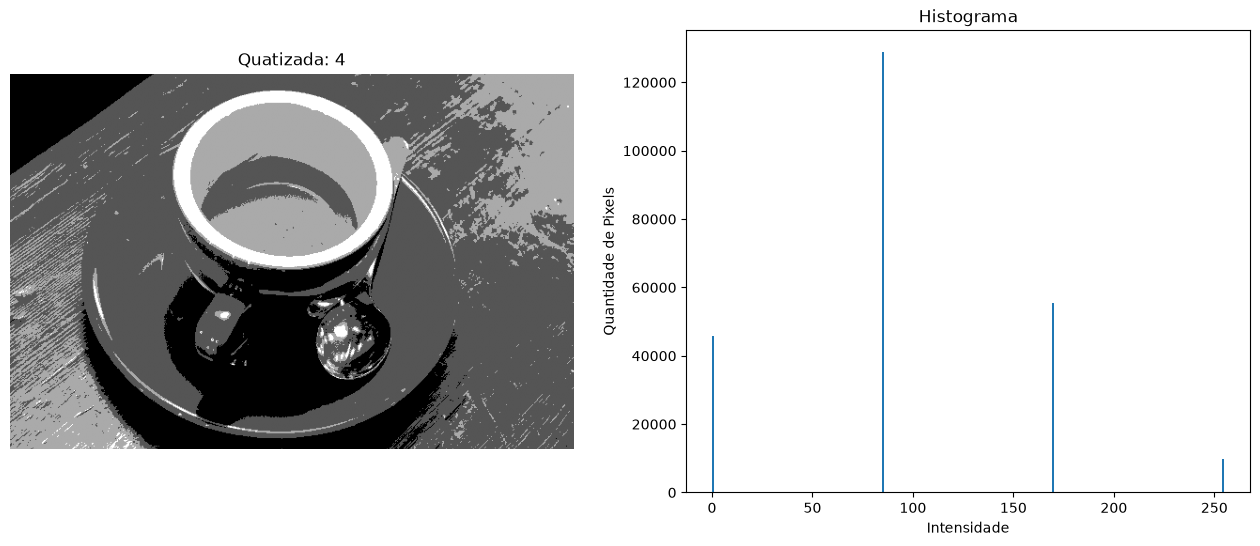

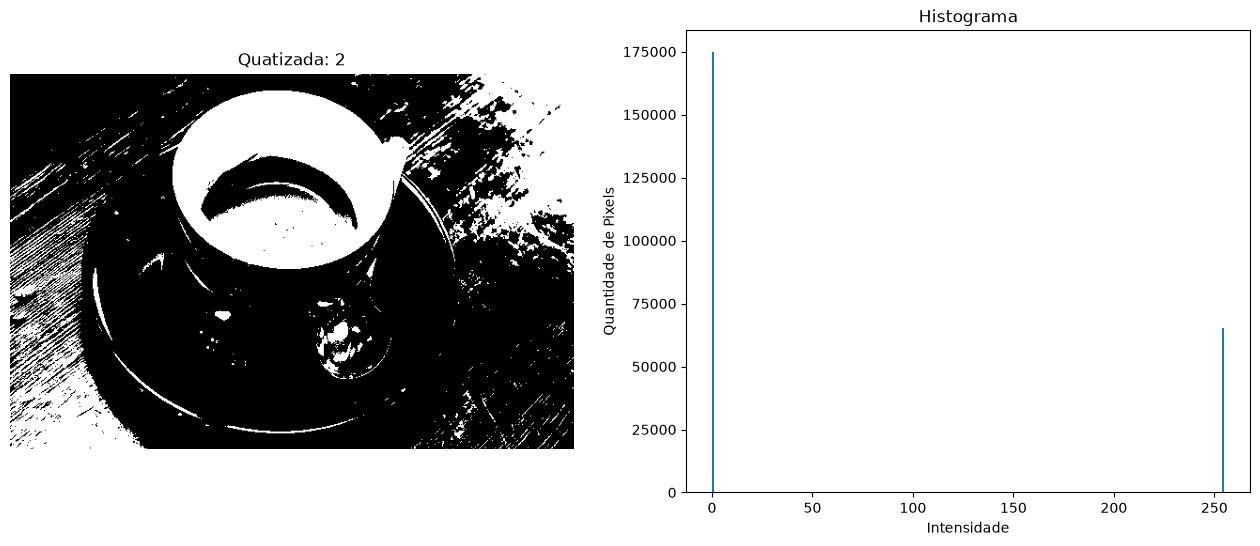

In [23]:
niveis = [256, 32, 16, 8, 4, 2]
# ravel() - Transforma matriz em um vetor
for quantidade in niveis:
    quantizada = quantizacao(
        cinza_media,
        quantidade 
    )

    mostrar_imagem_histograma(quantizada, f"Quatizada: {quantidade}")

